# 3. Spatially varying forcing

In [notebook 2](02_spatial_parameters.ipynb) every cell had its own
parameters but shared one climate. Forcing varies across a catchment too:
rain increases with elevation, each land use has its own crop calendar, and
irrigation districts have their own seasons and water sources.

A `GridForcing` gives each cell its own forcing. Each variable can be a
`(time, cell)` block, a series shared by every cell, a per-cell constant or a
single number, and the gap-filling rules of notebook 1 apply to each cell's
column.

This notebook:

1. builds per-cell forcing as an xarray Dataset on `(time, y, x)`, the shape
   gridded climate usually arrives in;
2. flattens it onto the model's `cell` axis, writes it to netCDF and reads it
   back as a `GridForcing`;
3. runs the valley from notebook 2 and compares it with the shared-climate
   run;
4. puts the results back on `(time, y, x)`, as annual maps and as the
   stress-period rates a groundwater model takes.

It needs xarray and a netCDF backend: `pip install "lumpyrem[xarray]"`.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import herebedragons as hbd
import lumpyrem as lr
import lumpyrem.io as lio

OUT_D = "output"
os.makedirs(OUT_D, exist_ok=True)

land = hbd.synthetic_landscape()
clim = hbd.load_climate()
nyears = (clim.index[-1] - clim.index[0]).days / 365.25

## 1. Forcing on a grid

### Rainfall that increases with elevation

The gauge sits on the valley floor. Rainfall is scaled from 85 % of the
gauge at the lowest cell to 125 % at the highest. Multiplying a `time`
series by a `(y, x)` map gives a `(time, y, x)` array.

In [2]:
height = (land.dem - land.dem.min()) / (land.dem.max() - land.dem.min())
rain_factor = 0.85 + 0.4 * height
rainfall = clim["rainfall"].to_xarray() * rain_factor
rainfall.dims, rainfall.shape

(('time', 'y', 'x'), (3627, 40, 60))

### Crop calendars by land use

Each land use has a monthly crop-factor curve. Native vegetation is steady,
pasture follows the wet season, and the irrigated crop is sown in spring and
fallow over winter.

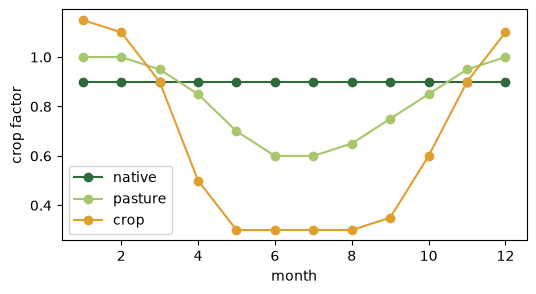

In [3]:
calendar = pd.DataFrame(
    {"native": [0.9] * 12,
     "pasture": [1.0, 1.0, 0.95, 0.85, 0.7, 0.6, 0.6, 0.65, 0.75, 0.85, 0.95, 1.0],
     "crop": [1.15, 1.1, 0.9, 0.5, 0.3, 0.3, 0.3, 0.3, 0.35, 0.6, 0.9, 1.1]},
    index=pd.Index(range(1, 13), name="month"),
)
calendar.plot(figsize=(6, 3), color=hbd.LANDUSE_COLORS, marker="o")
plt.ylabel("crop factor");

The curve is listed on the 15th of each month, and on the first and last
days of the run so that interpolation reaches both ends. Selecting a column
of the calendar by each cell's land-use code gives a `(time, y, x)` array.
Every other day is `NaN`, meaning "not listed", and the crop factor's
default rule interpolates between the listed days — cell by cell.

In [4]:
listed = (pd.date_range("1990-02-01", "1999-12-01", freq="MS") + pd.Timedelta(days=14)) \
    .union([clim.index[0], clim.index[-1]])
by_use = xr.DataArray(calendar.loc[listed.month].to_numpy(), dims=("time", "landuse"),
                      coords={"time": listed})
crop_factor = by_use.isel(landuse=land.landuse).reindex(time=clim.index)
crop_factor.dims, int(crop_factor.notnull().any(["y", "x"]).sum()), "days listed"

(('time', 'y', 'x'), 121, 'days listed')

`veg_gamma`, the curvature of the evaporation response, also follows land
use. Deep-rooted native vegetation keeps evaporating as the store dries; a
`(y, x)` map with no `time` axis is a per-cell constant.

In [5]:
veg_gamma = xr.DataArray([5.0, 2.0, 3.0], dims="landuse").isel(landuse=land.landuse)

### Irrigation districts

The valley has two irrigation districts. The west draws on a channel scheme
and may irrigate from October to March. The east pumps from bores, and water
restrictions limit it to November to February. Only crop cells irrigate.

Irrigation decisions are monthly, so `irrigate` is listed on the first of
each month and held until the next by its default forward fill. The source
of the water is a per-cell constant: `gw_irrig_frac` is 1 in the east, where
all of it is pumped from the aquifer, and 0 in the west.

In [6]:
east = (land.x > land.x.mean()).broadcast_like(land.dem)
crop = land.landuse == 2

decisions = pd.date_range(clim.index[0], clim.index[-1], freq="MS").union([clim.index[0]])
month = xr.DataArray(decisions.month, dims="time", coords={"time": decisions})
season = xr.where(east, month.isin([11, 12, 1, 2]), month.isin([10, 11, 12, 1, 2, 3]))
irrigate = (season & crop).astype(float).transpose("time", "y", "x").reindex(time=clim.index)
gw_irrig_frac = xr.where(east, 1.0, 0.0)

### One Dataset

Variables are named as `lumpyrem` names them. `pot_evap` is on `time` alone,
so every cell shares it.

In [7]:
ds = xr.Dataset({
    "rainfall": rainfall,
    "pot_evap": clim["pot_evap"].to_xarray(),
    "crop_factor": crop_factor,
    "veg_gamma": veg_gamma,
    "irrigate": irrigate,
    "gw_irrig_frac": gw_irrig_frac,
})
ds

<xarray.Dataset> Size: 209MB
Dimensions:        (time: 3627, y: 40, x: 60)
Coordinates:
  * time           (time) datetime64[us] 29kB 1990-01-31 ... 2000-01-05
  * y              (y) float64 320B 125.0 375.0 625.0 ... 9.625e+03 9.875e+03
  * x              (x) float64 480B 125.0 375.0 625.0 ... 1.462e+04 1.488e+04
Data variables:
    rainfall       (time, y, x) float64 70MB 0.0 0.0 0.0 ... 0.008439 0.00857
    pot_evap       (time) float64 29kB 0.007 0.0056 0.0086 ... 0.0062 0.0048
    crop_factor    (time, y, x) float64 70MB 1.0 1.0 1.0 1.0 ... 0.9 0.9 0.9 0.9
    veg_gamma      (y, x) float64 19kB 2.0 2.0 2.0 2.0 2.0 ... 5.0 5.0 5.0 5.0
    irrigate       (time, y, x) float64 70MB 0.0 0.0 0.0 0.0 ... nan nan nan nan
    gw_irrig_frac  (y, x) float64 19kB 0.0 0.0 0.0 0.0 0.0 ... 1.0 1.0 1.0 1.0

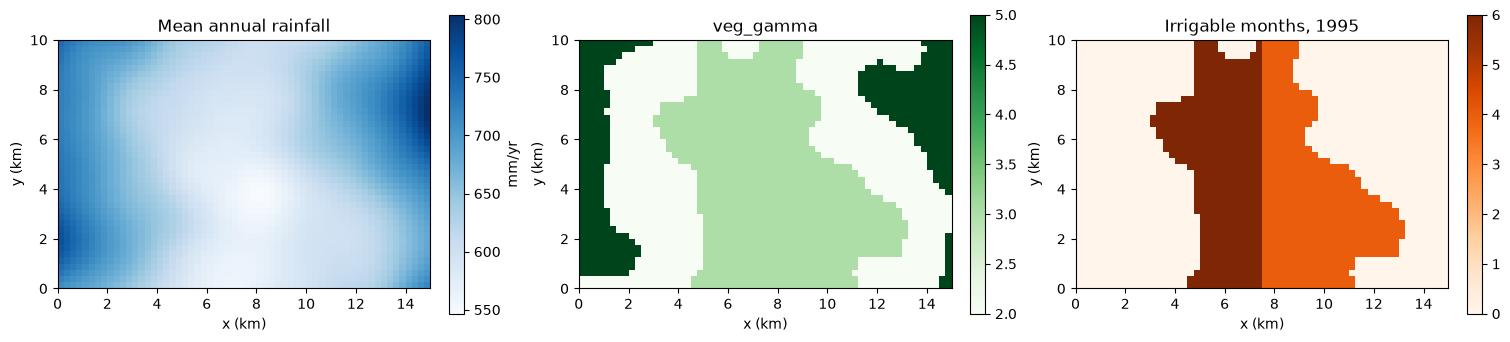

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3.6), layout="constrained")
hbd.plot_map(axs[0], ds.rainfall.sum("time") / nyears * 1000, land,
             title="Mean annual rainfall", label="mm/yr", cmap="Blues")
hbd.plot_map(axs[1], ds.veg_gamma, land, title="veg_gamma", cmap="Greens")
irrigable = ds.irrigate.sel(time=slice("1995-01-01", "1995-12-31")).sum("time")
hbd.plot_map(axs[2], irrigable, land, title="Irrigable months, 1995", cmap="Oranges");

`irrigate` is listed monthly, so summing its listed values counts months:
six in the west, four in the east, none outside the crops.

## 2. From `(time, y, x)` to the model's `cell` axis

A `ModelGrid` numbers its cells along one axis. Stacking `y` and `x` into
`cell` flattens the grid row by row, which is the numbering notebook 2 used.
Stacking leaves a pandas MultiIndex on `cell`, which netCDF cannot store, so
the forcing written to file keeps `cell` a plain integer and carries `y` and
`x` along as coordinates on it.

A Dataset that stays in memory can keep the MultiIndex:
`lio.forcing_from_dataset(ds.stack(cell=("y", "x")))` labels each cell with
its `(y, x)` pair, and `results.to_xarray(cell_levels=("y", "x"))` rebuilds
the MultiIndex on the results, so `.unstack("cell")` puts them straight back
on the grid.

In [9]:
stacked = ds.stack(cell=("y", "x")).reset_index("cell")
stacked = stacked.assign_coords(cell=np.arange(stacked.sizes["cell"]))
stacked

<xarray.Dataset> Size: 209MB
Dimensions:        (time: 3627, cell: 2400)
Coordinates:
  * time           (time) datetime64[us] 29kB 1990-01-31 ... 2000-01-05
  * cell           (cell) int64 19kB 0 1 2 3 4 5 ... 2395 2396 2397 2398 2399
    y              (cell) float64 19kB 125.0 125.0 125.0 ... 9.875e+03 9.875e+03
    x              (cell) float64 19kB 125.0 375.0 625.0 ... 1.462e+04 1.488e+04
Data variables:
    rainfall       (time, cell) float64 70MB 0.0 0.0 0.0 ... 0.008439 0.00857
    pot_evap       (time) float64 29kB 0.007 0.0056 0.0086 ... 0.0062 0.0048
    crop_factor    (time, cell) float64 70MB 1.0 1.0 1.0 1.0 ... 0.9 0.9 0.9 0.9
    veg_gamma      (cell) float64 19kB 2.0 2.0 2.0 2.0 2.0 ... 5.0 5.0 5.0 5.0
    irrigate       (time, cell) float64 70MB 0.0 0.0 0.0 0.0 ... nan nan nan nan
    gw_irrig_frac  (cell) float64 19kB 0.0 0.0 0.0 0.0 0.0 ... 1.0 1.0 1.0 1.0

The Dataset writes to netCDF like any other. The sparse and constant
variables compress well.

In [10]:
forcing_nc = os.path.join(OUT_D, "forcing.nc")
stacked.to_netcdf(forcing_nc, encoding={name: {"zlib": True, "complevel": 4}
                                        for name in stacked.data_vars})
f"{os.path.getsize(forcing_nc) / 1e6:.1f} MB"

'8.9 MB'

`lumpyrem.io.read_forcing` reads it back; `forcing_from_dataset` does the
same for a Dataset already in memory. A variable on `(time, cell)` becomes a
per-cell block, one on `cell` alone a per-cell constant, one on `time` alone
a shared series. The `cell` coordinate becomes the forcing's cell labels.

In [11]:
forcing = lio.read_forcing(forcing_nc)
print(forcing.ncell, "cells, labelled", forcing.cells[:3], "...")
print("per cell:", sorted(forcing.blocks))
print("shared:  ", sorted(forcing.series))

2400 cells, labelled (0, 1, 2) ...
per cell: ['crop_factor', 'gw_irrig_frac', 'irrigate', 'rainfall', 'veg_gamma']
shared:   ['pot_evap']


`to_daily` shows what the model will see, here for 1995 only. Each cell's
crop factor is interpolated from its own listed values, and `irrigate`
forward-fills from the month starts.

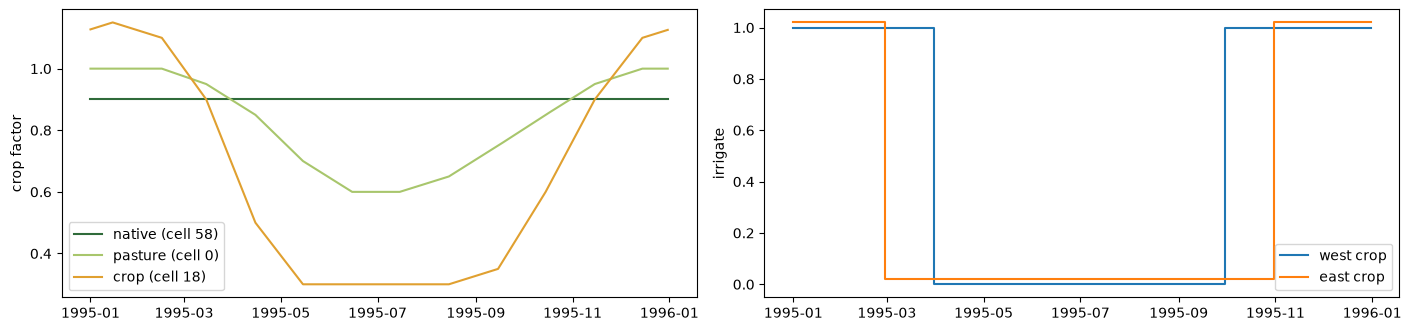

In [12]:
daily = forcing.to_daily("1995-01-01", "1995-12-31")
days = pd.date_range("1995-01-01", "1995-12-31")
use_code = land.landuse.values.ravel()
examples = {name: int(np.flatnonzero(use_code == i)[0])
            for i, name in enumerate(hbd.LANDUSE_CLASSES)}
east_cell = east.values.ravel()
east_crop = int(np.flatnonzero((use_code == 2) & east_cell)[0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 3.2), layout="constrained")
for (name, k), color in zip(examples.items(), hbd.LANDUSE_COLORS, strict=True):
    ax1.plot(days, daily["crop_factor"][:, k], color=color, label=f"{name} (cell {k})")
ax1.set_ylabel("crop factor")
ax1.legend()
ax2.step(days, daily["irrigate"][:, examples["crop"]], label="west crop")
ax2.step(days, daily["irrigate"][:, east_crop] + 0.02, label="east crop")
ax2.set_ylabel("irrigate")
ax2.legend();

Without xarray, `GridForcing.from_arrays` builds the same object from NumPy
arrays whose first axis is time: `(time, cell)` blocks, `(time,)` series, or
numbers.

In [13]:
from_numpy = lr.GridForcing.from_arrays(
    clim.index,
    rainfall=clim["rainfall"].to_numpy()[:, None] * rain_factor.values.ravel(),
    pot_evap=clim["pot_evap"].to_numpy(),
    veg_gamma=3.0,
)
from_numpy.ncell, sorted(from_numpy.blocks), sorted(from_numpy.series), from_numpy.constants

(2400, ['rainfall'], ['pot_evap'], {'veg_gamma': 3.0})

## 3. Running the valley

The parameters are those of notebook 2, rebuilt by `hbd.cell_parameters`
from the same tables. The grid takes its cell names from the forcing.

In [14]:
cells = hbd.cell_parameters(land)
grid = lr.ModelGrid.from_arrays(
    upper=dict(
        maxvol=cells["maxvol"].to_numpy(),
        ks=cells["ks"].to_numpy(),
        m=cells["m"].to_numpy(),
        l=0.5,
        mflowmax=cells["mflowmax"].to_numpy(),
        irrigvolfrac=cells["irrigvolfrac"].to_numpy(),
        rdelay=cells["rdelay"].to_numpy(),
        mdelay=1.0,
    ),
    initial=dict(vol=0.5 * cells["maxvol"].to_numpy()),
    names=forcing.cells,
)
results = grid.run(forcing, times="MS")
results

<GridResults: 2400 cells x 120 output times, 1990-01-31 to 2000-01-01, converged>

Labelled forcing must match the grid's names, in order, so forcing read from
a file cannot be applied to the wrong cells.

In [15]:
shuffled = lr.ModelGrid(cells=grid.cells, names=grid.names[::-1])
try:
    shuffled.run(forcing, times="MS")
except lr.ModelError as err:
    print(err)

the forcing's cell labels do not match the grid's names, in order; pass names=forcing.cells when building the grid, or reorder the forcing


For comparison, the shared climate of notebook 2: gauge rainfall everywhere,
a crop factor of 1, one `veg_gamma` and one irrigation season.

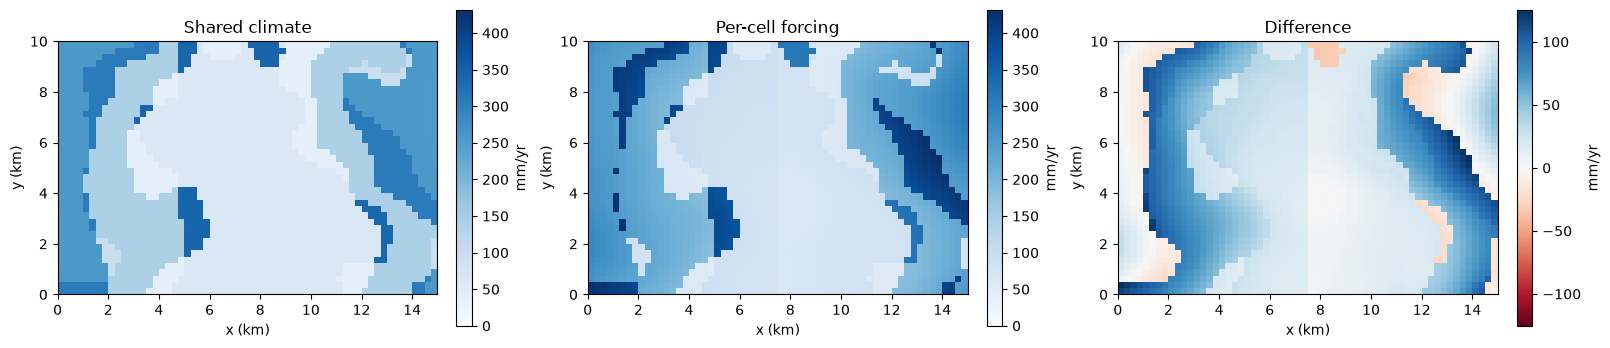

In [16]:
shared = lr.Forcing.from_dataframe(
    clim.assign(irrigate=hbd.season_flag(clim.index, months=(10, 11, 12, 1, 2, 3))),
    veg_gamma=3.0, gw_irrig_frac=0.5)
baseline = grid.run(shared, times="MS")

rech = results["total_rech"].sum() / nyears * 1000
rech_base = baseline["total_rech"].sum() / nyears * 1000

fig, axs = plt.subplots(1, 3, figsize=(16, 3.8), layout="constrained")
vmax = float(max(rech.max(), rech_base.max()))
hbd.plot_map(axs[0], rech_base, land, title="Shared climate", label="mm/yr",
             cmap="Blues", vmin=0, vmax=vmax)
hbd.plot_map(axs[1], rech, land, title="Per-cell forcing", label="mm/yr",
             cmap="Blues", vmin=0, vmax=vmax)
lim = float(np.abs(rech - rech_base).max())
hbd.plot_map(axs[2], rech - rech_base, land, title="Difference", label="mm/yr",
             cmap="RdBu", vmin=-lim, vmax=lim);

The change is not simply the rainfall gradient. Breaking it down by land use
and district shows what the vegetation does with the water:

In [17]:
district = np.where(east_cell, "east", "west")
change = pd.DataFrame({
    name: (results[name].sum() - baseline[name].sum()).to_numpy() / nyears * 1000
    for name in ("rainfall", "irrigation", "evap_upper", "total_rech")
})
change.groupby([cells["landuse"], district]).mean().round(0) \
    .rename_axis(index=["landuse", "district"], columns="change, mm/yr")

change, mm/yr     rainfall  irrigation  evap_upper  total_rech
landuse district                                              
crop    east         -53.0      -125.0      -185.0         9.0
        west         -54.0       -55.0      -133.0        26.0
native  east          89.0         0.0        83.0         7.0
        west          77.0         0.0        79.0        -1.0
pasture east          12.0         0.0       -55.0        65.0
        west          15.0         0.0       -54.0        66.0

- On the ridges, native vegetation receives 80–90 mm/yr more rain and, with
  its higher `veg_gamma`, evaporates nearly all of it, so its recharge
  barely moves.
- Pasture recharges about 65 mm/yr more, because its crop factor falls below
  1 through the dry season.
- Crops on the floor receive less rain and less irrigation, but their winter
  fallow cuts evaporation by more than both, so their recharge rises a little
  — least in the east, where the irrigation season is shorter.

Irrigation now differs by district. The shorter eastern season applies less
water, and all of it is pumped, so the east carries the groundwater
withdrawal.

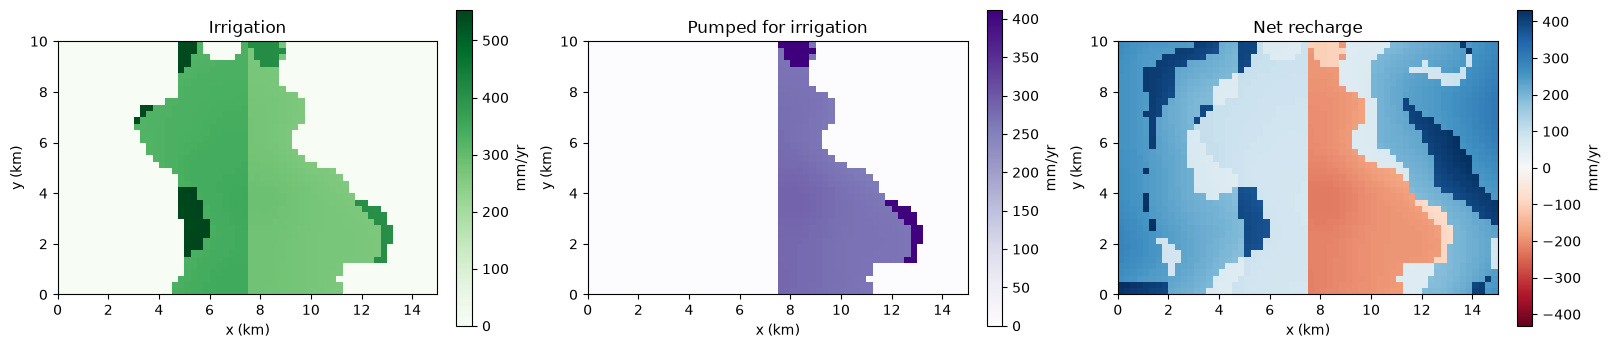

In [18]:
irr = results["irrigation"].sum() / nyears * 1000
pumped = results["gw_withdrawal"].sum() / nyears * 1000
net = results["net_recharge"].sum() / nyears * 1000

fig, axs = plt.subplots(1, 3, figsize=(16, 3.8), layout="constrained")
hbd.plot_map(axs[0], irr, land, title="Irrigation", label="mm/yr", cmap="Greens")
hbd.plot_map(axs[1], pumped, land, title="Pumped for irrigation", label="mm/yr",
             cmap="Purples")
lim = float(np.abs(net).max())
hbd.plot_map(axs[2], net, land, title="Net recharge", label="mm/yr", cmap="RdBu",
             vmin=-lim, vmax=lim);

In [19]:
crops = cells["landuse"].to_numpy() == "crop"
pd.DataFrame({"irrigation": irr, "pumped": pumped, "recharge": rech, "net": net})[crops] \
    .groupby(district[crops]).mean().round(0).rename_axis("crop cells, mm/yr")

,irrigation,pumped,recharge,net
"crop cells, mm/yr",,,,
east,283.0,283.0,92.0,-191.0
west,360.0,0.0,119.0,119.0


## 4. Results as maps

`results.to_xarray()` gives a Dataset on `(time, cell)`, one variable per
output column. Attaching the `y` and `x` coordinates from the stacked forcing
and unstacking `cell` puts it back on the grid.

In [20]:
out = results.to_xarray()
out = out.assign_coords(y=stacked.y, x=stacked.x).set_index(cell=["y", "x"]).unstack("cell")
out[["total_rech", "net_recharge", "vol_upper"]]

<xarray.Dataset> Size: 7MB
Dimensions:       (time: 121, y: 40, x: 60)
Coordinates:
  * time          (time) datetime64[ns] 968B 1990-01-31 ... 2000-01-01
    day           (time) int64 968B 0 1 29 60 90 ... 3500 3530 3561 3591 3622
  * y             (y) float64 320B 125.0 375.0 625.0 ... 9.625e+03 9.875e+03
  * x             (x) float64 480B 125.0 375.0 625.0 ... 1.462e+04 1.488e+04
Data variables:
    total_rech    (time, y, x) float64 2MB 0.0 0.0 0.0 ... 0.03393 0.0301
    net_recharge  (time, y, x) float64 2MB 0.0 0.0 0.0 ... 0.03393 0.0301
    vol_upper     (time, y, x) float64 2MB 0.05 0.05 0.05 ... 0.03799 0.03845
Attributes:
    source:           lumpyrem 0.0.2
    time_convention:  time labels the end of each reporting interval; the fir...

From here it is ordinary xarray. Each row of the results labels the *end* of
its interval, so a day is subtracted from the time before grouping by year.

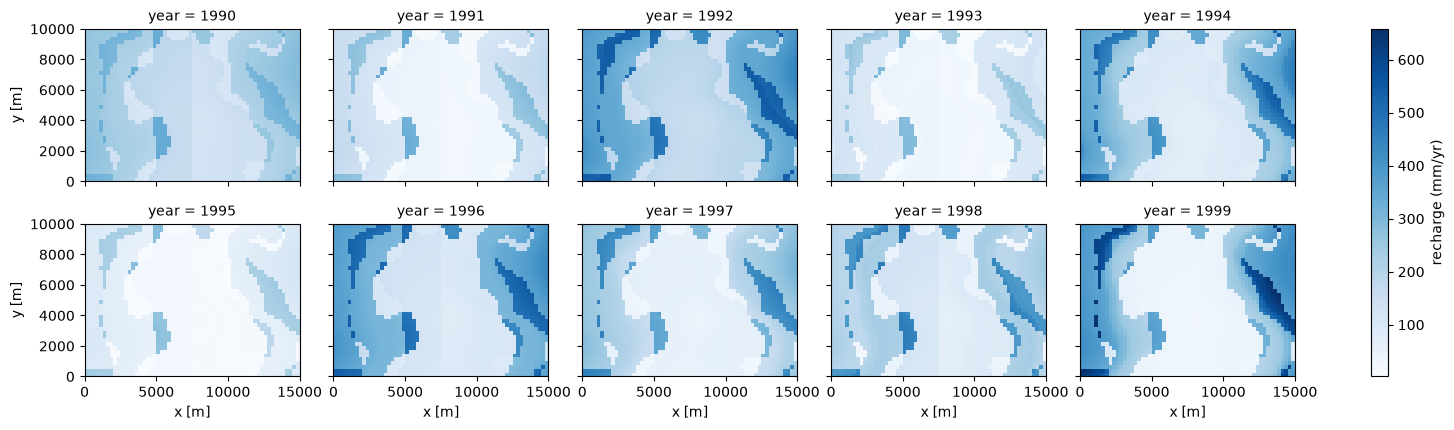

In [21]:
monthly = out.total_rech.isel(time=slice(1, None))
year = (monthly.time - pd.Timedelta(days=1)).dt.year.rename("year")
annual = monthly.groupby(year).sum() * 1000
annual.attrs["units"] = "mm"
annual.plot(col="year", col_wrap=5, cmap="Blues", size=2.2, aspect=1.4,
            cbar_kwargs=dict(label="recharge (mm/yr)"));

### Stress-period rates

Flux columns are totals over each interval. A groundwater model takes a
rate, so divide by the interval's length in days. `day` counts simulation
days, and its difference is each interval's length, labelled by the
interval's end, as the results are.

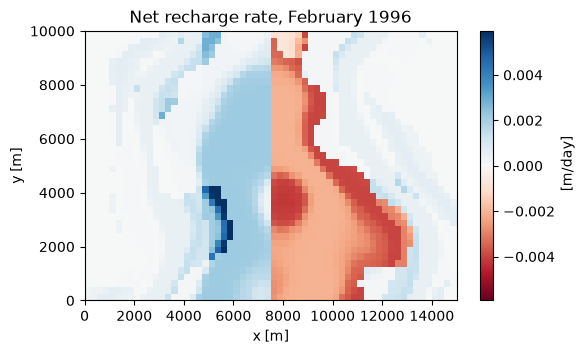

In [22]:
ndays = out.day.diff("time")
rate = out.net_recharge.isel(time=slice(1, None)) / ndays
rate.attrs["units"] = "m/day"
rate.sel(time="1996-03-01").plot(cmap="RdBu", center=0, figsize=(6, 3.5))
plt.title("Net recharge rate, February 1996");

Writing the gridded results is one call. `GridResults.to_netcdf` writes the
`(time, cell)` form directly, if that is what a downstream tool wants.

In [23]:
recharge_nc = os.path.join(OUT_D, "recharge.nc")
out[["total_rech", "net_recharge", "evap_upper", "vol_upper"]].to_netcdf(recharge_nc)
xr.load_dataset(recharge_nc)

<xarray.Dataset> Size: 9MB
Dimensions:       (time: 121, y: 40, x: 60)
Coordinates:
  * time          (time) datetime64[ns] 968B 1990-01-31 ... 2000-01-01
    day           (time) int64 968B 0 1 29 60 90 ... 3500 3530 3561 3591 3622
  * y             (y) float64 320B 125.0 375.0 625.0 ... 9.625e+03 9.875e+03
  * x             (x) float64 480B 125.0 375.0 625.0 ... 1.462e+04 1.488e+04
Data variables:
    total_rech    (time, y, x) float64 2MB 0.0 0.0 0.0 ... 0.03393 0.0301
    net_recharge  (time, y, x) float64 2MB 0.0 0.0 0.0 ... 0.03393 0.0301
    evap_upper    (time, y, x) float64 2MB 0.0 0.0 0.0 ... 0.04224 0.04272
    vol_upper     (time, y, x) float64 2MB 0.05 0.05 0.05 ... 0.03799 0.03845
Attributes:
    source:           lumpyrem 0.0.2
    time_convention:  time labels the end of each reporting interval; the fir...

## Where next

Handing a `(time, cell)` recharge array to a MODFLOW 6 RCH package through
flopy, and writing LR2SERIES-style time series, is the next phase of the
port (`docs/conversion-plan.md`, Phase 4). Until then, `rate` above is the
array such a package takes, one stress period per output time.